# CDS in-situ surface-land — demo

End-to-end demo for the CDS [`insitu-observations-surface-land`](https://cds.climate.copernicus.eu/datasets/insitu-observations-surface-land) adapter: the `.env` → `CDSSource` → `CDSInsituArchive` pipeline, with a GeoParquet round-trip and a station map.

> **First-time setup.** Land has dataset-specific licences that the CDS portal gates behind a one-time *accept* click. If this notebook's `archive.sync(...)` call 403s with `required licences not accepted`, visit the dataset page above, click **Manage licences**, accept each required licence, then re-run the cell.

Credentials live in the project-root `.env`:

```
CDSAPI_URL=https://cds.climate.copernicus.eu/api
CDSAPI_KEY=<uid>:<api-key>
```

Land uses `data_format=csv`, accepts a server-side `area` filter, takes **one year per request** (the archive chunks by year), and **requires** `time_aggregation` ∈ `{sub_daily, daily, monthly}` on every request.

Scope: 2020, Iberia bbox, `time_aggregation=daily`, default variables. Pulls a single-year CSV zip per request.

## 1. Set up the adapter and archive

In [1]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

from xrtoolz.data import CDSInsituArchive, CDSSource
from xrtoolz.types import BBox

In [2]:
import os
from pathlib import Path

def _default_scratch_root(subdir: str) -> Path:
    """Same resolver as scripts/_cds_insitu_common._default_scratch_root."""
    for var in ("CDS_INSITU_SCRATCH_ROOT", "XR_TOOLZ_CDS_ROOT"):
        override = os.environ.get(var)
        if override:
            return Path(override).expanduser() / subdir
    shared = Path("/home/azureuser/cloudfiles/code/Users/adm.jjohnson72/scratch")
    if shared.is_dir():
        return shared / "cds_insitu" / subdir
    # Last-resort local fallback. Repo .gitignore excludes scratch/.
    return Path.cwd() / "scratch" / subdir

scratch = _default_scratch_root('land_demo')
archive = CDSInsituArchive(
    root=scratch,
    preset='cds_insitu_land',
    source=CDSSource(),  # reads CDSAPI_URL / CDSAPI_KEY from .env
    time_aggregation="daily",  # required by the CDS form
)
archive.preset_root

PosixPath('/home/azureuser/cloudfiles/code/Users/adm.jjohnson72/scratch/cds_insitu/land_demo/cds_insitu_land')

## 2. Sync one year over Iberia

Year-chunked; the archive records the completed chunk in `manifest.json` and re-running is a no-op.

In [3]:
bbox = BBox(lon_min=-10.0, lon_max=3.5, lat_min=35.5, lat_max=44.0)
fresh = archive.sync("2020-01-01", "2020-12-31", bbox=bbox)
len(fresh)

2026-04-24 14:41:39,227 INFO Request ID is a597af7e-04c7-4b8c-9fda-e6cf530bcdb5


2026-04-24 14:41:39,365 INFO status has been updated to accepted


Recovering from connection error [('Connection aborted.', RemoteDisconnected('Remote end closed connection without response'))], attempt 1 of 500


Retrying in 120 seconds


2026-04-24 14:46:25,823 INFO status has been updated to running


...

8945b55f9a4a0bff200fd72b8d85317a.zip:  64%|██████▍   | 23.0M/36.0M [00:01<00:00, 24.7MB/s]

8945b55f9a4a0bff200fd72b8d85317a.zip:  75%|███████▌  | 27.0M/36.0M [00:02<00:00, 28.4MB/s]

8945b55f9a4a0bff200fd72b8d85317a.zip:  86%|████████▌ | 31.0M/36.0M [00:02<00:00, 31.2MB/s]

8945b55f9a4a0bff200fd72b8d85317a.zip:  97%|█████████▋| 35.0M/36.0M [00:02<00:00, 33.2MB/s]

232250

## 3. Read back the GeoParquet archive

In [4]:
gdf = archive.load()
gdf.head()

,station_id,time,lon,lat,variable,value,units,quality_flag,report_type,source_id,geometry
0,MOM00060318,2020-01-01 00:00:00+00:00,-5.320,35.594,air_temperature,290.45,K,0,3,166,POINT (-5.32 35.594)
1,MOM00060318,2020-01-01 00:00:00+00:00,-5.320,35.594,accumulated_precipitation,0.00,mm,0,3,166,POINT (-5.32 35.594)
2,MOM00060318,2020-01-01 00:00:00+00:00,-5.320,35.594,air_temperature,286.95,K,0,3,166,POINT (-5.32 35.594)
3,AGM00060490,2020-01-01 00:00:00+00:00,-0.621,35.624,accumulated_precipitation,0.00,mm,0,3,166,POINT (-0.621 35.624)
4,AGM00060490,2020-01-01 00:00:00+00:00,-0.621,35.624,air_temperature,281.75,K,0,3,166,POINT (-0.621 35.624)


In [5]:
gdf.groupby("variable").size().sort_values(ascending=False)

variable
air_temperature              163834
accumulated_precipitation     68132
snow_depth                      284
dtype: int64

## 4. Station locations

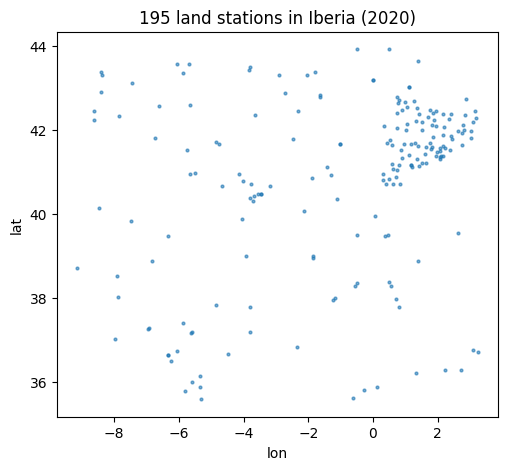

In [6]:
stations = archive.load_stations()
fig, ax = plt.subplots(figsize=(9, 5))
stations.plot(ax=ax, markersize=4, color="tab:blue", alpha=0.6)
ax.set_xlabel("lon")
ax.set_ylabel("lat")
ax.set_title(f"{len(stations)} land stations in Iberia (2020)")
plt.show()

## 5. Daily mean per variable

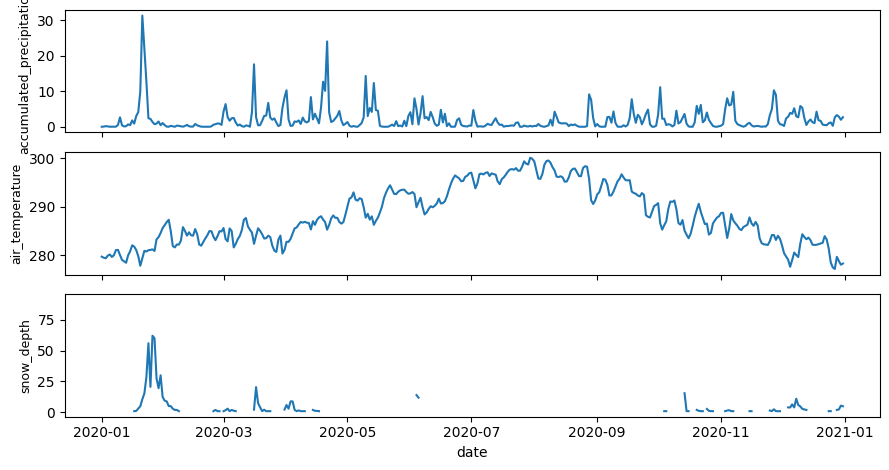

In [7]:
ts = (
    gdf.groupby(["variable", pd.Grouper(key="time", freq="1D")])["value"]
    .mean()
    .unstack("variable")
)
fig, axes = plt.subplots(len(ts.columns), 1, figsize=(9, 1.6 * len(ts.columns)), sharex=True)
for ax, var in zip(axes, ts.columns, strict=True):
    ax.plot(ts.index, ts[var])
    ax.set_ylabel(var, fontsize=9)
axes[-1].set_xlabel("date")
plt.tight_layout()
plt.show()